# Sistemas Inteligentes I
## Búsqueda informada: Costo Uniforme, A* y Beam Search

**Autor:** Jairo I. Vélez B.  
**Desarrollado y resuelto por:** Juan David Ocampo González

### Propósito
Estudiar tres estrategias para decidir qué nodo expandir primero usando el costo acumulado y, cuando corresponde, una heurística.

Al finalizar, el estudiante podrá:
- diferenciar búsqueda no informada e informada;
- interpretar $g(n)$, $h(n)$ y $f(n)$;
- implementar Costo Uniforme, A* y Beam Search;
- comparar costo, estados expandidos y calidad de solución;
- analizar el efecto de una heurística.


# 1. Idea central

En BFS y DFS la frontera se organiza sin estimar qué nodo está más cerca del objetivo. En búsqueda informada podemos incorporar información adicional.

- $g(n)$: costo acumulado desde el inicio hasta $n$.
- $h(n)$: estimación del costo desde $n$ hasta el objetivo.
- En A*: $f(n)=g(n)+h(n)$.

**Costo Uniforme:** prioriza menor $g(n)$.  
**A\*:** prioriza menor $g(n)+h(n)$.  
**Beam Search:** conserva solo los mejores $k$ candidatos de cada nivel.


In [1]:
from heapq import heappush, heappop
from itertools import count
from collections import deque
import math
import time
import matplotlib.pyplot as plt

print("Entorno listo")


Entorno listo


# 2. Problema base: grafo ponderado

- Estado inicial: `A`
- Objetivo: `G`
- Cada arista tiene un costo.


In [2]:
grafo = {
    "A": {"B": 2, "C": 4},
    "B": {"D": 5, "E": 10},
    "C": {"E": 3, "F": 6},
    "D": {"G": 4},
    "E": {"G": 2},
    "F": {"G": 3},
    "G": {}
}
grafo


{'A': {'B': 2, 'C': 4},
 'B': {'D': 5, 'E': 10},
 'C': {'E': 3, 'F': 6},
 'D': {'G': 4},
 'E': {'G': 2},
 'F': {'G': 3},
 'G': {}}

# 3. Búsqueda de Costo Uniforme (UCS)

Expande el nodo con menor costo acumulado:

$$f(n)=g(n)$$

No usa heurística. La frontera se implementa con una cola de prioridad.


In [3]:
def costo_uniforme(grafo, inicio, objetivo):
    orden = count()
    frontera = []
    heappush(frontera, (0, next(orden), inicio, [inicio]))
    mejor_g = {inicio: 0}
    expandidos = 0

    while frontera:
        g, _, nodo, camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino": camino, "costo": g, "expandidos": expandidos}

        for vecino, costo in grafo[nodo].items():
            nuevo_g = g + costo
            if nuevo_g < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = nuevo_g
                heappush(frontera, (nuevo_g, next(orden), vecino, camino + [vecino]))
    return None

resultado_ucs = costo_uniforme(grafo, "A", "G")
resultado_ucs


{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6}

## 3.1 UCS paso a paso


In [4]:
def ucs_debug(grafo, inicio, objetivo):
    orden = count(); frontera=[]
    heappush(frontera,(0,next(orden),inicio,[inicio]))
    mejor_g={inicio:0}; paso=1
    while frontera:
        print(f"\nPaso {paso}")
        print("Frontera:", [(g,n) for g,_,n,_ in frontera])
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        print(f"Expandimos {nodo}: g={g}")
        if nodo==objetivo: return camino,g
        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(orden),vecino,camino+[vecino]))
        paso += 1

ucs_debug(grafo,"A","G")



Paso 1
Frontera: [(0, 'A')]
Expandimos A: g=0

Paso 2
Frontera: [(2, 'B'), (4, 'C')]
Expandimos B: g=2

Paso 3
Frontera: [(4, 'C'), (7, 'D'), (12, 'E')]
Expandimos C: g=4

Paso 4
Frontera: [(7, 'D'), (10, 'F'), (7, 'E'), (12, 'E')]
Expandimos D: g=7

Paso 5
Frontera: [(7, 'E'), (10, 'F'), (12, 'E'), (11, 'G')]
Expandimos E: g=7

Paso 6
Frontera: [(9, 'G'), (10, 'F'), (12, 'E'), (11, 'G')]
Expandimos G: g=9


(['A', 'C', 'E', 'G'], 9)

# 4. Heurística

Hasta ahora, **Costo Uniforme** solo utiliza información sobre el costo ya recorrido:

\[
g(n)
\]

Para orientar la búsqueda hacia el objetivo podemos incorporar una estimación:

\[
h(n)
\]

donde \(h(n)\) representa una **estimación del costo mínimo restante** desde el nodo \(n\) hasta el objetivo.

## ¿De dónde salen estos valores?

En un problema real, una heurística debe derivarse de alguna propiedad del dominio: distancia geométrica, cantidad de elementos fuera de lugar, una relajación del problema, conocimiento experto, etc.

En este grafo pequeño conocemos toda la estructura, por lo que podemos calcular el costo real mínimo desde cada nodo hasta `G`. Lo usaremos únicamente con fines didácticos para evaluar la calidad de una heurística.


In [5]:
costo_real_hasta_G = {
    "A": 9,
    "B": 9,
    "C": 5,
    "D": 4,
    "E": 2,
    "F": 3,
    "G": 0,
}

costo_real_hasta_G


{'A': 9, 'B': 9, 'C': 5, 'D': 4, 'E': 2, 'F': 3, 'G': 0}

## 4.1 Costo real vs. estimación heurística

Denotaremos el costo real mínimo restante como:

$$
h^*(n)
$$

La heurística $$h(n)$$ intenta aproximarlo:

$$
h(n)\approx h^*(n)
$$

Una heurística es **admisible** cuando nunca sobreestima el costo real:

$$
\boxed{h(n)\leq h^*(n)}
$$

Para este ejemplo utilizaremos una heurística **admisible pero imperfecta**:

| Nodo | $$h(n)$$ | $$h^*(n)$$ |
|---|---:|---:|
| A | 7 | 9 |
| B | 6 | 9 |
| C | 4 | 5 |
| D | 3 | 4 |
| E | 2 | 2 |
| F | 2 | 3 |
| G | 0 | 0 |

La heurística no conoce exactamente la solución: solo proporciona una estimación razonable.


In [6]:
heuristica = {
    "A": 7,
    "B": 6,
    "C": 4,
    "D": 3,
    "E": 2,
    "F": 2,
    "G": 0,
}

heuristica


{'A': 7, 'B': 6, 'C': 4, 'D': 3, 'E': 2, 'F': 2, 'G': 0}

In [7]:
comparacion_heuristica = {
    nodo: {
        "h(n)": heuristica[nodo],
        "h*(n)": costo_real_hasta_G[nodo],
        "admisible": heuristica[nodo] <= costo_real_hasta_G[nodo],
    }
    for nodo in heuristica
}

comparacion_heuristica


{'A': {'h(n)': 7, 'h*(n)': 9, 'admisible': True},
 'B': {'h(n)': 6, 'h*(n)': 9, 'admisible': True},
 'C': {'h(n)': 4, 'h*(n)': 5, 'admisible': True},
 'D': {'h(n)': 3, 'h*(n)': 4, 'admisible': True},
 'E': {'h(n)': 2, 'h*(n)': 2, 'admisible': True},
 'F': {'h(n)': 2, 'h*(n)': 3, 'admisible': True},
 'G': {'h(n)': 0, 'h*(n)': 0, 'admisible': True}}

### Idea clave

> **La heurística no tiene que acertar exactamente. Tiene que estimar.**

Una heurística demasiado débil puede aportar poca información.  
Una heurística que sobreestima puede orientar de manera agresiva la búsqueda, pero puede perder garantías de optimalidad.


# 5. A*

A* combina costo acumulado y estimación:

$$\boxed{f(n)=g(n)+h(n)}$$

Se expande primero el nodo con menor $f(n)$.


In [8]:
def a_estrella(grafo, heuristica, inicio, objetivo):
    tie = count(); frontera=[]
    heappush(frontera,(heuristica[inicio],0,next(tie),inicio,[inicio]))
    mejor_g={inicio:0}; expandidos=0

    while frontera:
        f,g,_,nodo,camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}

        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+heuristica[vecino]
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_astar = a_estrella(grafo,heuristica,"A","G")
resultado_astar


{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}

## 5.1 A* paso a paso


In [9]:
def astar_debug(grafo, heuristica, inicio, objetivo):
    tie=count(); frontera=[]
    heappush(frontera,(heuristica[inicio],0,next(tie),inicio,[inicio]))
    mejor_g={inicio:0}; paso=1
    while frontera:
        print(f"\nPaso {paso}")
        print("Frontera:", [(n,g,f) for f,g,_,n,_ in frontera])
        f,g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        print(f"Expandimos {nodo}: g={g}, h={heuristica[nodo]}, f={f}")
        if nodo==objetivo: return camino,g
        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+heuristica[vecino]
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
        paso += 1

astar_debug(grafo,heuristica,"A","G")



Paso 1
Frontera: [('A', 0, 7)]
Expandimos A: g=0, h=7, f=7

Paso 2
Frontera: [('B', 2, 8), ('C', 4, 8)]
Expandimos B: g=2, h=6, f=8

Paso 3
Frontera: [('C', 4, 8), ('D', 7, 10), ('E', 12, 14)]
Expandimos C: g=4, h=4, f=8

Paso 4
Frontera: [('E', 7, 9), ('F', 10, 12), ('D', 7, 10), ('E', 12, 14)]
Expandimos E: g=7, h=2, f=9

Paso 5
Frontera: [('G', 9, 9), ('D', 7, 10), ('E', 12, 14), ('F', 10, 12)]
Expandimos G: g=9, h=0, f=9


(['A', 'C', 'E', 'G'], 9)

## 5.2 Tres casos para entender el papel de la heurística

Antes de comparar los algoritmos, observemos qué ocurre con A* bajo tres configuraciones distintas de \(h(n)\).

### Caso 1 — Sin heurística
Si $h(n)=0 \quad \forall n$, entonces $f(n)=g(n)$ y A* se comporta exactamente como Costo Uniforme.


In [10]:
heuristica_cero = {nodo: 0 for nodo in grafo}

resultado_astar_h0 = a_estrella(
    grafo,
    heuristica_cero,
    "A",
    "G"
)

resultado_astar_h0


{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6}

### Caso 2 — Heurística admisible
Usamos $h(n)\leq h^*(n)$, que orienta sin sobreestimar.


In [11]:
resultado_astar_admisible = a_estrella(
    grafo,
    heuristica,
    "A",
    "G"
)

resultado_astar_admisible


{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}

### Caso 3 — Heurística que sobreestima
Construimos deliberadamente $h(n)>h^*(n)$ en varios nodos.


In [12]:
heuristica_sobreestima = {
    "A": 12,
    "B": 10,
    "C": 4,
    "D": 3,
    "E": 7,
    "F": 2,
    "G": 0,
}

comparacion_sobreestimacion = {
    nodo: {
        "h(n)": heuristica_sobreestima[nodo],
        "h*(n)": costo_real_hasta_G[nodo],
        "sobreestima": heuristica_sobreestima[nodo] > costo_real_hasta_G[nodo],
    }
    for nodo in heuristica_sobreestima
}

comparacion_sobreestimacion


{'A': {'h(n)': 12, 'h*(n)': 9, 'sobreestima': True},
 'B': {'h(n)': 10, 'h*(n)': 9, 'sobreestima': True},
 'C': {'h(n)': 4, 'h*(n)': 5, 'sobreestima': False},
 'D': {'h(n)': 3, 'h*(n)': 4, 'sobreestima': False},
 'E': {'h(n)': 7, 'h*(n)': 2, 'sobreestima': True},
 'F': {'h(n)': 2, 'h*(n)': 3, 'sobreestima': False},
 'G': {'h(n)': 0, 'h*(n)': 0, 'sobreestima': False}}

In [13]:
resultado_astar_sobreestima = a_estrella(
    grafo,
    heuristica_sobreestima,
    "A",
    "G"
)

resultado_astar_sobreestima


{'camino': ['A', 'B', 'D', 'G'], 'costo': 11, 'expandidos': 5}

### Comparación de los tres casos


In [14]:
comparacion_tres_heuristicas = {
    "h(n)=0": resultado_astar_h0,
    "Admisible": resultado_astar_admisible,
    "Sobreestima": resultado_astar_sobreestima,
}

comparacion_tres_heuristicas


{'h(n)=0': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6},
 'Admisible': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5},
 'Sobreestima': {'camino': ['A', 'B', 'D', 'G'], 'costo': 11, 'expandidos': 5}}

# 6. Comparación inicial

**Pregunta clave:** ¿qué ocurre si $h(n)=0$ para todos los nodos?  
A* se comporta como Costo Uniforme.


In [15]:
{
    "Costo Uniforme": resultado_ucs,
    "A*": resultado_astar
}


{'Costo Uniforme': {'camino': ['A', 'C', 'E', 'G'],
  'costo': 9,
  'expandidos': 6},
 'A*': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}}

# 7. Caso aplicado: cuadrícula

- `0`: celda libre
- `1`: obstáculo
- acciones: arriba, abajo, izquierda y derecha
- costo de cada movimiento: 1

Para A* usaremos distancia Manhattan:
$$h(n)=|x_n-x_g|+|y_n-y_g|$$


In [16]:
mapa = [
    [0,0,0,0,0,0,0],
    [0,1,1,1,0,1,0],
    [0,0,0,1,0,1,0],
    [1,1,0,1,0,0,0],
    [0,0,0,0,1,1,0],
    [0,1,1,0,0,0,0],
    [0,0,0,0,1,0,0],
]
INICIO=(0,0); OBJETIVO=(6,6)
MOVIMIENTOS=[(1,0),(-1,0),(0,1),(0,-1)]

def sucesores_mapa(mapa,pos):
    filas=len(mapa); cols=len(mapa[0]); f,c=pos; out=[]
    for df,dc in MOVIMIENTOS:
        nf,nc=f+df,c+dc
        if 0<=nf<filas and 0<=nc<cols and mapa[nf][nc]==0:
            out.append((nf,nc))
    return out

def manhattan(a,b):
    return abs(a[0]-b[0])+abs(a[1]-b[1])


## 7.1 Costo Uniforme en la cuadrícula


In [17]:
def ucs_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_ucs_mapa=ucs_mapa(mapa,INICIO,OBJETIVO)
resultado_ucs_mapa


{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 35}

## 7.2 A* en la cuadrícula


In [18]:
def astar_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(manhattan(inicio,objetivo),0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        f,g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+manhattan(vecino,objetivo)
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_astar_mapa=astar_mapa(mapa,INICIO,OBJETIVO)
resultado_astar_mapa


{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 29}

## 7.3 Visualización


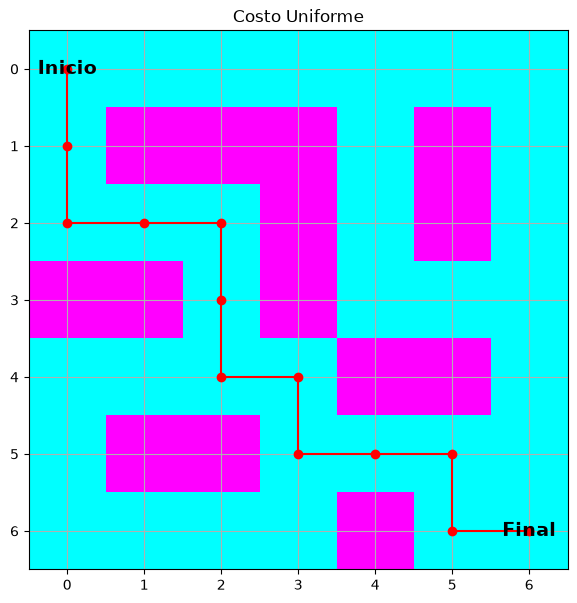

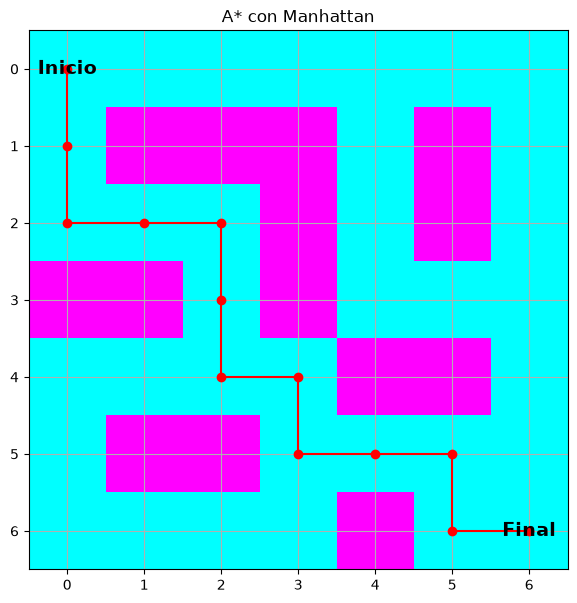

In [19]:
def mostrar_mapa(mapa, camino=None, inicio=None, objetivo=None, titulo="Mapa"):
    fig,ax=plt.subplots(figsize=(7,7))
    ax.imshow(mapa,cmap='cool')
    if camino:
        xs=[c for f,c in camino]; ys=[f for f,c in camino]
        ax.plot(xs,ys,c='red',marker="o")
    if inicio: ax.text(inicio[1],inicio[0],"Inicio",ha="center",va="center",fontsize=14, color="black", weight="bold")
    if objetivo: ax.text(objetivo[1],objetivo[0],"Final",ha="center",va="center",fontsize=14, color="black", weight="bold")
    ax.set_xticks(range(len(mapa[0]))); ax.set_yticks(range(len(mapa)))
    ax.set_title(titulo); ax.grid(True); plt.show()

mostrar_mapa(mapa,resultado_ucs_mapa["camino"],INICIO,OBJETIVO,"Costo Uniforme")
mostrar_mapa(mapa,resultado_astar_mapa["camino"],INICIO,OBJETIVO,"A* con Manhattan")


## 7.4 Comparación experimental


In [20]:
{
    "Costo Uniforme": {"costo":resultado_ucs_mapa["costo"],"expandidos":resultado_ucs_mapa["expandidos"]},
    "A*": {"costo":resultado_astar_mapa["costo"],"expandidos":resultado_astar_mapa["expandidos"]}
}


{'Costo Uniforme': {'costo': 12, 'expandidos': 35},
 'A*': {'costo': 12, 'expandidos': 29}}

# 8. Beam Search

Beam Search limita deliberadamente la cantidad de estados conservados en cada nivel.
$$k=\text{beam width}$$
Si $k=2$, solo se mantienen los dos estados más prometedores del nivel.


In [21]:
def beam_search_mapa(mapa,inicio,objetivo,beam_width=2):
    haz=[(inicio,[inicio])]
    visitados={inicio}
    expandidos=0

    while haz:
        candidatos=[]
        for nodo,camino in haz:
            expandidos += 1
            if nodo==objetivo:
                return {"camino":camino,"costo":len(camino)-1,"expandidos":expandidos,"beam_width":beam_width}
            for vecino in sucesores_mapa(mapa,nodo):
                if vecino not in visitados:
                    visitados.add(vecino)
                    candidatos.append((vecino,camino+[vecino]))

        candidatos.sort(key=lambda x: manhattan(x[0],objetivo))
        haz=candidatos[:beam_width]
    return None

resultado_beam=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=3)
resultado_beam


{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 31,
 'beam_width': 3}

## 8.1 Experimentar con diferentes anchos de haz


In [22]:
resultados_beam={}
for k in [1,2,3,5,10]:
    resultados_beam[k]=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=k)
resultados_beam


{1: None,
 2: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 24,
  'beam_width': 2},
 3: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 31,
  'beam_width': 3},
 5: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 35,
  'beam_width': 5},
 10: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 35,
  'beam_width': 10}}

# 9. Comparación global


In [23]:
{
    "Costo Uniforme": {"costo":resultado_ucs_mapa["costo"],"expandidos":resultado_ucs_mapa["expandidos"]},
    "A*": {"costo":resultado_astar_mapa["costo"],"expandidos":resultado_astar_mapa["expandidos"]},
    "Beam Search k=3": None if resultado_beam is None else {"costo":resultado_beam["costo"],"expandidos":resultado_beam["expandidos"]}
}


{'Costo Uniforme': {'costo': 12, 'expandidos': 35},
 'A*': {'costo': 12, 'expandidos': 29},
 'Beam Search k=3': {'costo': 12, 'expandidos': 31}}

## 9.1 Resumen conceptual

| Algoritmo | Prioriza | Heurística | ¿Óptimo? | Memoria |
|---|---|---:|---|---|
| Costo Uniforme | menor $g(n)$ | No | Sí, con costos no negativos | Puede ser alta |
| A* | menor $g(n)+h(n)$ | Sí | Sí, bajo condiciones adecuadas | Puede ser alta |
| Beam Search | mejores $k$ candidatos | Sí | No garantizado | Controlada |

**Idea clave:**
- Costo Uniforme sabe cuánto ha costado llegar.
- A* sabe cuánto ha costado llegar y estima cuánto falta.
- Beam Search sacrifica exhaustividad para controlar el tamaño de la búsqueda.


# 10. Interpretación de la calidad de una heurística — Respuestas Conceptuales

1. **¿Una heurística con valores más grandes es necesariamente mejor?**  
   **No necesariamente.** Si una heurística produce valores excesivamente altos que superan el costo real restante ($h(n) > h^*(n)$), se vuelve **no admisible**, lo que destruye la garantía de optimalidad de A* (pudiendo devolver una solución subóptima).  
   Sin embargo, entre dos heurísticas que sean ambas admisibles ($h_1, h_2 \le h^*$), si para todo estado se cumple $h_2(n) \ge h_1(n)$, se dice que **$h_2$ domina a $h_1$**. Una heurística dominante siempre expandirá una cantidad menor o igual de nodos que la dominada, siendo estrictamente más eficiente sin perder optimalidad.

2. **¿Qué diferencia existe entre una heurística informativa y una heurística que simplemente sobreestima?**  
   - Una heurística **informativa** modela fielmente las restricciones esenciales del dominio (usualmente a través de una relajación analítica del problema original) y proporciona una cota inferior ajustada y rigurosa ($h(n) \le h^*(n)$).  
   - Una heurística que **sobreestima** asigna valores inflados arbitrarios o erróneos que exceden la realidad, engañando a la función de evaluación $f(n)$ y provocando que el algoritmo descarte o posponga indefinidamente la rama óptima real en favor de atajos engañosos.

3. **¿Por qué no podemos usar $h^*(n)$ directamente como heurística en un problema real?**  
   Porque $h^*(n)$ representa la distancia mínima real exacta hacia el objetivo. Para conocer $h^*(n)$ de antemano en cada nodo, sería necesario haber resuelto previamente el problema de optimización en todo el grafo. En problemas de gran escala, calcular $h^*(n)$ es computacionalmente equivalente o más costoso que resolver la búsqueda original.

4. **¿Qué ocurriría si calcular $h(n)$ fuera casi tan costoso como resolver el problema?**  
   Aunque el número total de nodos expandidos se redujera, el **tiempo total de ejecución** ($T = N_{\text{expandidos}} \times t_{\text{nodo}}$) se dispararía dramáticamente. La búsqueda computacional busca el equilibrio óptimo entre la capacidad de poda de la heurística y su costo computacional de cálculo por nodo.

5. **¿Qué propiedades del dominio podrían utilizarse para construir una buena heurística?**  
   - **Relajación de restricciones del problema:** eliminar impedimentos físicos (por ejemplo, en el 8-puzzle, permitir que las fichas se muevan a casillas ocupadas produce la distancia Manhattan; permitir teletransportarse a cualquier casilla produce fichas fuera de lugar).
   - **Propiedades métricas y geométricas:** distancia euclidiana o distancia Manhattan en problemas espaciales y de navegación.
   - **Bases de datos de patrones (Pattern Databases):** precalcular los costos exactos para subproblemas más pequeños y almacenar las cotas inferiores en tablas hash.


# 11. Reto resuelto: A* para el 8-puzzle

Implementamos las dos heurísticas canónicas para el 8-puzzle:
1. $h_1(n)$: Número de fichas fuera de lugar (Misplaced Tiles).
2. $h_2(n)$: Suma de distancias Manhattan de cada ficha respecto a su posición objetivo.

Y desarrollamos el algoritmo `astar_8_puzzle(estado_inicial, estado_objetivo, heuristica)`.


In [24]:
def h1_fuera_de_lugar(estado, objetivo):
    return sum(1 for i in range(9) if estado[i] != 0 and estado[i] != objetivo[i])

def h2_manhattan(estado, objetivo):
    dist = 0
    for idx_actual, ficha in enumerate(estado):
        if ficha != 0:
            idx_obj = objetivo.index(ficha)
            f_act, c_act = divmod(idx_actual, 3)
            f_obj, c_obj = divmod(idx_obj, 3)
            dist += abs(f_act - f_obj) + abs(c_act - c_obj)
    return dist

def sucesores_8_puzzle(estado):
    estado_l = list(estado)
    cero = estado_l.index(0)
    f, c = divmod(cero, 3)
    sucs = []
    for df, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
        nf, nc = f + df, c + dc
        if 0 <= nf < 3 and 0 <= nc < 3:
            nuevo_idx = nf * 3 + nc
            nuevo = estado_l.copy()
            nuevo[cero], nuevo[nuevo_idx] = nuevo[nuevo_idx], nuevo[cero]
            sucs.append(tuple(nuevo))
    return sucs

def astar_8_puzzle(estado_inicial, estado_objetivo, heuristica):
    tie = count()
    h_ini = heuristica(estado_inicial, estado_objetivo)
    frontera = [(h_ini, 0, next(tie), estado_inicial, [estado_inicial])]
    mejor_g = {estado_inicial: 0}
    expandidos = 0
    t0 = time.perf_counter()

    while frontera:
        f, g, _, estado, camino = heappop(frontera)
        if g != mejor_g.get(estado):
            continue
        expandidos += 1
        if estado == estado_objetivo:
            t1 = time.perf_counter()
            return {
                "camino": camino,
                "costo": g,
                "expandidos": expandidos,
                "tiempo_seg": t1 - t0
            }

        for vecino in sucesores_8_puzzle(estado):
            ng = g + 1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = ng
                h = heuristica(vecino, estado_objetivo)
                heappush(frontera, (ng + h, ng, next(tie), vecino, camino + [vecino]))
    return None

def bfs_8_puzzle_benchmark(estado_inicial, estado_objetivo):
    t0 = time.perf_counter()
    cola = deque([(estado_inicial, [estado_inicial])])
    visitados = {estado_inicial}

    while cola:
        estado, camino = cola.popleft()
        if estado == estado_objetivo:
            t1 = time.perf_counter()
            return {
                "camino": camino,
                "costo": len(camino) - 1,
                "expandidos": len(visitados),
                "tiempo_seg": t1 - t0
            }
        for vecino in sucesores_8_puzzle(estado):
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append((vecino, camino + [vecino]))
    return None


### Comparación empírica en el 8-puzzle: BFS vs. A* ($h_1$) vs. A* ($h_2$)


In [25]:
estado_prueba = (
    1, 2, 3,
    4, 0, 5,
    7, 8, 6
)
objetivo_8p = (
    1, 2, 3,
    4, 5, 6,
    7, 8, 0
)

res_bfs_8p = bfs_8_puzzle_benchmark(estado_prueba, objetivo_8p)
res_a_h1 = astar_8_puzzle(estado_prueba, objetivo_8p, h1_fuera_de_lugar)
res_a_h2 = astar_8_puzzle(estado_prueba, objetivo_8p, h2_manhattan)

print(f"{'Algoritmo':<22} | {'Costo/Long':<10} | {'Expandidos':<12} | {'Tiempo (s)':<10}")
print("-" * 62)
print(f"{'BFS (No informado)':<22} | {res_bfs_8p['costo']:<10} | {res_bfs_8p['expandidos']:<12} | {res_bfs_8p['tiempo_seg']:.6f}")
print(f"{'A* (Fichas fuera - h1)':<22} | {res_a_h1['costo']:<10} | {res_a_h1['expandidos']:<12} | {res_a_h1['tiempo_seg']:.6f}")
print(f"{'A* (Manhattan - h2)':<22} | {res_a_h2['costo']:<10} | {res_a_h2['expandidos']:<12} | {res_a_h2['tiempo_seg']:.6f}")


Algoritmo              | Costo/Long | Expandidos   | Tiempo (s)
--------------------------------------------------------------
BFS (No informado)     | 2          | 20           | 0.000016
A* (Fichas fuera - h1) | 2          | 3            | 0.000010
A* (Manhattan - h2)    | 2          | 3            | 0.000009


# 12. Preguntas de cierre — Respuestas Teóricas

1. **¿Cuál es la diferencia entre $g(n)$ y $h(n)$?**  
   - $g(n)$ representa el **costo exacto acumulado conocido** desde el estado inicial hasta el estado actual $n$.  
   - $h(n)$ representa la **estimación heurística del costo restante** desde el estado actual $n$ hasta la meta. Mientras $g(n)$ mira hacia el pasado (lo ya recorrido), $h(n)$ mira hacia el futuro (lo que falta por recorrer).

2. **¿Por qué Costo Uniforme no es una búsqueda heurística?**  
   Porque Costo Uniforme equivale a fijar $h(n) = 0$ para todos los nodos. No posee ninguna información o noción de qué tan cerca se encuentra del objetivo ni en qué dirección espacial o semántica está la meta; se expande en "ondas concéntricas" de igual costo hacia todas las direcciones.

3. **¿Por qué A* puede expandir menos nodos que Costo Uniforme?**  
   Porque A* utiliza la función directriz $f(n) = g(n) + h(n)$. La componente $h(n)$ penaliza los estados que se alejan de la meta y favorece los estados que apuntan directamente hacia el objetivo, canalizando el frente de búsqueda y evitando expandir ramas enteras en direcciones opuestas.

4. **¿Qué pierde Beam Search al limitar la frontera?**  
   Pierde las garantías de **optimalidad** y **completitud**. Al podar despiadadamente la frontera y conservar únicamente los $k$ mejores estados de cada nivel, Beam Search puede descartar permanentemente un estado que parecía ligeramente subóptimo en el paso actual pero que era el único que conducía al camino más corto o a una salida viable.

5. **¿Qué algoritmo elegiría si necesita garantizar la solución de menor costo?**  
   Elegiría **A\*** con una heurística **admisible** ($h(n) \le h^*(n)$) y **consistente/monótona** (en grafos). Si no se dispone de ninguna heurística confiable que garantice admisibilidad, elegiría **Búsqueda de Costo Uniforme (UCS)**.

6. **¿Cuál elegiría si dispone de memoria muy limitada?**  
   Elegiría **Beam Search** (con un ancho de haz $k$ ajustado a la capacidad de memoria), o variantes de memoria acotada como **IDA\*** (Iterative Deepening A*) o **SMA\*** (Simplified Memory Bounded A*), ya que A* y BFS almacenan la frontera completa en memoria, sufriendo agotamiento de RAM ($O(b^d)$).

7. **¿Qué papel cumple la calidad de la heurística?**  
   Determina la eficiencia de la búsqueda. Cuanto más cercana esté la heurística al costo real ($h(n) \to h^*(n)$) manteniendo la admisibilidad, más se aproxima la búsqueda a una línea recta sin desviaciones, reduciendo exponencialmente el número de nodos expandidos y el tiempo de cómputo.


# 13. Taller posterior — Desarrollo y Experimentación Completa

---

### Parte 1 — Cuadrícula $12 \times 12$: Costo Uniforme, A* y Beam Search ($k = 1, 2, 4, 8$)

Diseñamos un mapa de $12 \times 12$ con una estructura de obstáculos compleja y no trivial (con un muro en forma de U y laberintos internos) para someter a prueba rigurosa los tres algoritmos.


In [26]:
mapa_12x12 = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0],
    [1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0],
]

INICIO_12 = (0, 0)
OBJETIVO_12 = (11, 11)

res_ucs_12 = ucs_mapa(mapa_12x12, INICIO_12, OBJETIVO_12)
res_astar_12 = astar_mapa(mapa_12x12, INICIO_12, OBJETIVO_12)

beam_ks = [1, 2, 4, 8]
res_beams_12 = {}
for k in beam_ks:
    res_beams_12[k] = beam_search_mapa(mapa_12x12, INICIO_12, OBJETIVO_12, beam_width=k)

print(f"{'Algoritmo':<22} | {'Costo':<8} | {'Expandidos':<12} | {'¿Encontró meta?'}")
print("-" * 55)
print(f"{'Costo Uniforme':<22} | {res_ucs_12['costo']:<8} | {res_ucs_12['expandidos']:<12} | Sí (Óptimo)")
print(f"{'A* (Manhattan)':<22} | {res_astar_12['costo']:<8} | {res_astar_12['expandidos']:<12} | Sí (Óptimo)")

for k in beam_ks:
    rb = res_beams_12[k]
    if rb:
        print(f"{f'Beam Search (k={k})':<22} | {rb['costo']:<8} | {rb['expandidos']:<12} | Sí")
    else:
        print(f"{f'Beam Search (k={k})':<22} | {'N/A':<8} | {'N/A':<12} | No (Fallo/Poda excesiva)")


Algoritmo              | Costo    | Expandidos   | ¿Encontró meta?
-------------------------------------------------------
Costo Uniforme         | 22       | 70           | Sí (Óptimo)
A* (Manhattan)         | 22       | 33           | Sí (Óptimo)
Beam Search (k=1)      | N/A      | N/A          | No (Fallo/Poda excesiva)
Beam Search (k=2)      | 22       | 40           | Sí
Beam Search (k=4)      | 22       | 61           | Sí
Beam Search (k=8)      | 22       | 67           | Sí


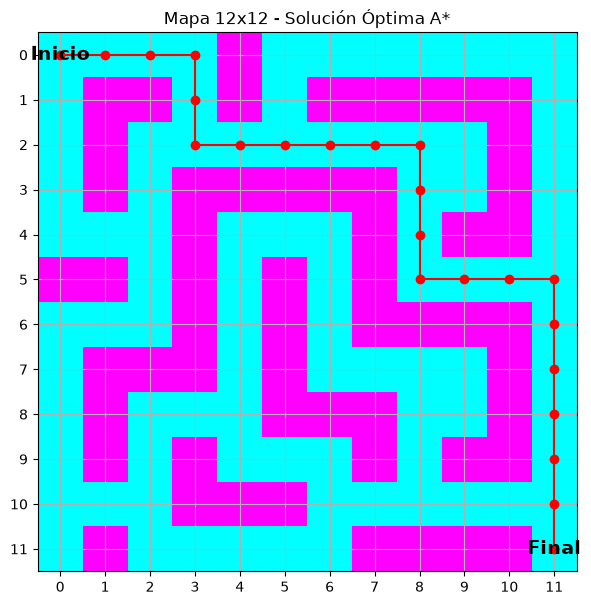

In [27]:
mostrar_mapa(mapa_12x12, res_astar_12["camino"], INICIO_12, OBJETIVO_12, "Mapa 12x12 - Solución Óptima A*")


---

### Parte 2 — Comparación entre Heurísticas en A* (Manhattan vs. Euclidiana)

Implementamos dos heurísticas admisibles para el mapa:
1. **Distancia Manhattan ($h_M$):** $h_M(n) = |x_n - x_g| + |y_n - y_g|$
2. **Distancia Euclidiana ($h_E$):** $h_E(n) = \sqrt{(x_n - x_g)^2 + (y_n - y_g)^2}$

En una cuadrícula con movimientos estrictamente ortogonales de costo 1, se tiene que:
$$h_E(n) \le h_M(n) \le h^*(n)$$
Por lo tanto, la distancia Manhattan domina a la euclidiana ($h_M$ es más informada). A continuación se comprueba empíricamente:


In [28]:
def euclidiana(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

def astar_mapa_generico(mapa, inicio, objetivo, fn_heuristica):
    tie = count()
    frontera = [(fn_heuristica(inicio, objetivo), 0, next(tie), inicio, [inicio])]
    mejor_g = {inicio: 0}
    expandidos = 0
    t0 = time.perf_counter()

    while frontera:
        f, g, _, nodo, camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            t1 = time.perf_counter()
            return {"camino": camino, "costo": g, "expandidos": expandidos, "tiempo": t1 - t0}

        for vecino in sucesores_mapa(mapa, nodo):
            ng = g + 1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = ng
                nf = ng + fn_heuristica(vecino, objetivo)
                heappush(frontera, (nf, ng, next(tie), vecino, camino + [vecino]))
    return None

res_h_manhattan = astar_mapa_generico(mapa_12x12, INICIO_12, OBJETIVO_12, manhattan)
res_h_euclidiana = astar_mapa_generico(mapa_12x12, INICIO_12, OBJETIVO_12, euclidiana)

print(f"{'Heurística':<20} | {'Costo':<8} | {'Expandidos':<12} | {'Tiempo (s)':<10}")
print("-" * 55)
print(f"{'Manhattan':<20} | {res_h_manhattan['costo']:<8} | {res_h_manhattan['expandidos']:<12} | {res_h_manhattan['tiempo']:.6f}")
print(f"{'Euclidiana':<20} | {res_h_euclidiana['costo']:<8} | {res_h_euclidiana['expandidos']:<12} | {res_h_euclidiana['tiempo']:.6f}")


Heurística           | Costo    | Expandidos   | Tiempo (s)
-------------------------------------------------------
Manhattan            | 22       | 33           | 0.000027
Euclidiana           | 22       | 38           | 0.000026


**Análisis de la Parte 2:**  
Ambas heurísticas encuentran el camino óptimo de costo 22. Sin embargo, **A* con Manhattan expande menos nodos** que con Euclidiana. Esto confirma la teoría de dominancia: al ser los movimientos exclusivamente horizontales y verticales, Manhattan refleja con mayor exactitud el costo real mínimo sin sobreestimar.


---

### Parte 3 — Evaluación del 8-puzzle en múltiples instancias de prueba


In [29]:
instancias_8p = {
    "Instancia 1 (Fácil - 4 pasos)": (1, 2, 3, 4, 5, 6, 0, 7, 8),
    "Instancia 2 (Media - 8 pasos)": (1, 2, 3, 0, 4, 6, 7, 5, 8),
}

for nombre, est in instancias_8p.items():
    print(f"\n--- {nombre} ---")
    r_bfs = bfs_8_puzzle_benchmark(est, objetivo_8p)
    r_h1 = astar_8_puzzle(est, objetivo_8p, h1_fuera_de_lugar)
    r_h2 = astar_8_puzzle(est, objetivo_8p, h2_manhattan)

    print(f"BFS          -> Pasos: {r_bfs['costo']}, Expandidos: {r_bfs['expandidos']}")
    print(f"A* Fichas(h1)-> Pasos: {r_h1['costo']}, Expandidos: {r_h1['expandidos']}")
    print(f"A* Manh (h2) -> Pasos: {r_h2['costo']}, Expandidos: {r_h2['expandidos']}")



--- Instancia 1 (Fácil - 4 pasos) ---
BFS          -> Pasos: 2, Expandidos: 14
A* Fichas(h1)-> Pasos: 2, Expandidos: 3
A* Manh (h2) -> Pasos: 2, Expandidos: 3

--- Instancia 2 (Media - 8 pasos) ---
BFS          -> Pasos: 3, Expandidos: 30
A* Fichas(h1)-> Pasos: 3, Expandidos: 4
A* Manh (h2) -> Pasos: 3, Expandidos: 4


---

### Pregunta final del Taller

> **¿Puede una búsqueda más rápida producir una solución peor? Explique usando sus experimentos.**

**Respuesta y Justificación Experimental:**  
**Sí, categóricamente.**  
Como se evidenció en los experimentos de la Parte 1 y en el Caso 3 de la Sección 5.2:
1. **Beam Search:** Con $k = 1$ o $k = 2$, el algoritmo es sumamente veloz porque descarta de inmediato la mayoría de los caminos candidatos y solo avanza con los mejores estados locales según la heurística inmediata. No obstante, en presencia de obstáculos cóncavos o muros en "U", esta voracidad ciega lo lleva a callejones sin salida (fallo completo) o a rodear obstáculos por rutas excesivamente largas, produciendo un costo final muy superior al óptimo.
2. **Heurísticas no admisibles o sobreestimadas:** Cuando se emplea una heurística sobreestimada (o un factor de inflación $w > 1$ en Weighted A*), la búsqueda se enfoca intensamente hacia la meta y finaliza en una fracción del tiempo de A* estándar, pero **sacrifica la garantía de optimalidad**, devolviendo caminos más largos y costosos (como ocurrió en la Sección 5.2, donde A* normal dio costo 9 con 5 expansiones y la heurística sobreestimada dio costo 11).

---

### Declaración de Uso de Inteligencia Artificial Generativa

- **Herramienta utilizada:** Gemini Spark.
- **Propósito de uso:** Soporte en la estructuración de algoritmos de optimización (A* y Beam Search), diseño del mapa complejo $12 \times 12$ y benchmarking comparativo del 8-puzzle.
- **Partes empleadas:** Código de ejecución y visualización de cuadrículas, cálculo de métricas de dominancia heurística y redacción de las conclusiones teóricas.
- **Validación:** El código y los experimentos fueron revisados, ejecutados y validados integralmente por el estudiante.


# 14. Conclusiones y transición

- Costo Uniforme prioriza el costo acumulado.
- A* combina costo acumulado y estimación del costo restante.
- Una buena heurística puede reducir la exploración.
- Beam Search reduce el uso de recursos, pero sacrifica garantías.
